# Multiple Items and Constraints

Often businesses sell more than one product, and have have real world considerations like a stock budget, storage limitations, manufacturing time, or even weight for transportation costs. This notebook serves as an introduction into solving these problems. Again, we will use the bakery and muffin example.

## Multiple Items

If there are no constraints but multiple items, the problem becomes separable. Meaning, the optimum solution for one item does not impact the optimum solution for the other products and we can therefore solve each problem independently as many single item problems instead one problem with many items.

The more interesting case is if we have a constraint to consider. Lets use the example of the bakery selling plain muffins and chocolate muffins, but now the bakery has a total ingredient budget, and needs to find the optimum stock allocation for each.

- use a greedy alogrthym
- defualts to cost of item

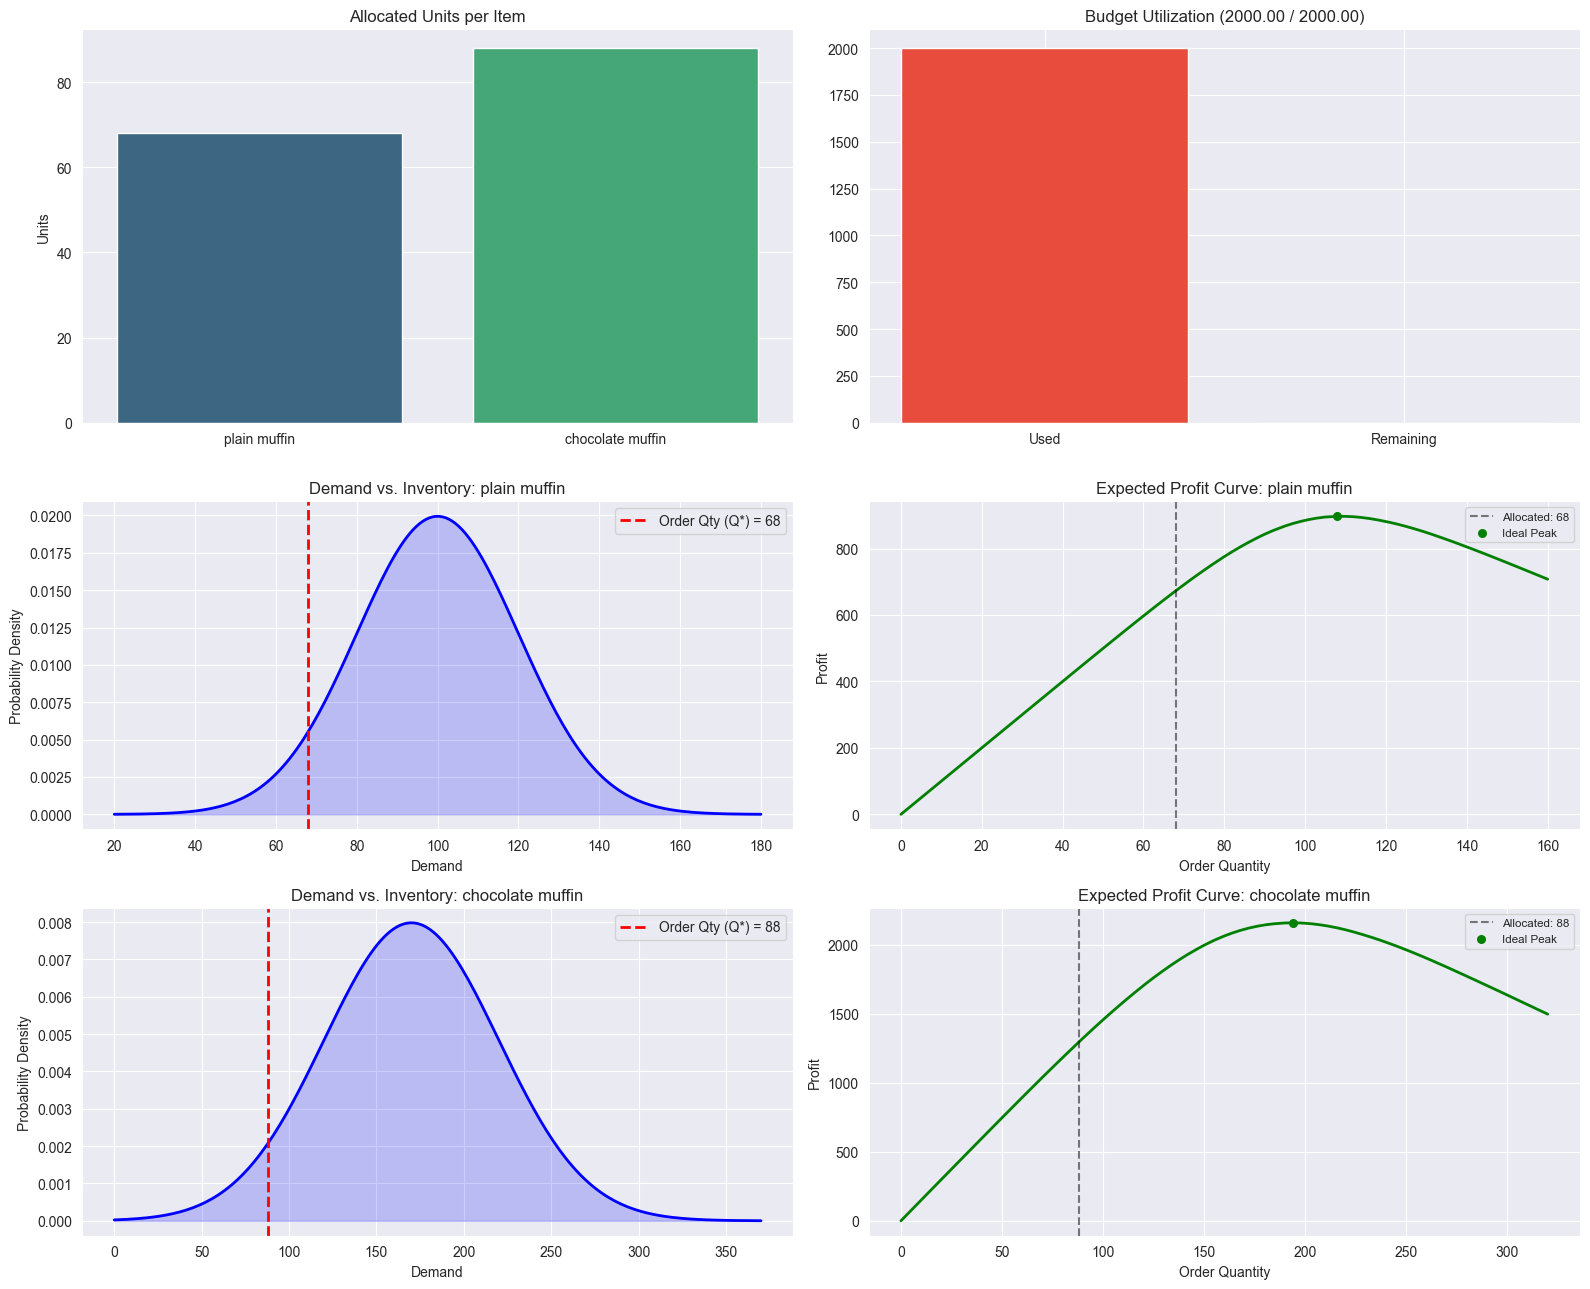

In [19]:
from inventory_management.items import Item
from inventory_management.distributions.demand_distributions import NormalDemand
from inventory_management.solvers import MultiItemConstrainedSolver
from inventory_management.plot_suite.portfolio import plot_multi_item_allocation


plain_muffin = Item("plain muffin", cost_price=10, selling_price=20, salvage_value=5)
chocolate_muffin = Item(
    "chocolate muffin", cost_price=15, selling_price=30, salvage_value=8
)

plain_demand = NormalDemand(100, 20)
chocolate_demand = NormalDemand(170, 50)

inventory_problems = problems = [
    (plain_muffin, plain_demand),
    (chocolate_muffin, chocolate_demand),
]

opt_allocation = MultiItemConstrainedSolver(inventory_problems, budget=2000).solve()
fig = plot_multi_item_allocation(opt_allocation, problems, budget=2000)

## multiple constraints

c:\Users\bouwe\anaconda3\envs\inventory_env\Lib\site-packages\scipy\optimize\_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


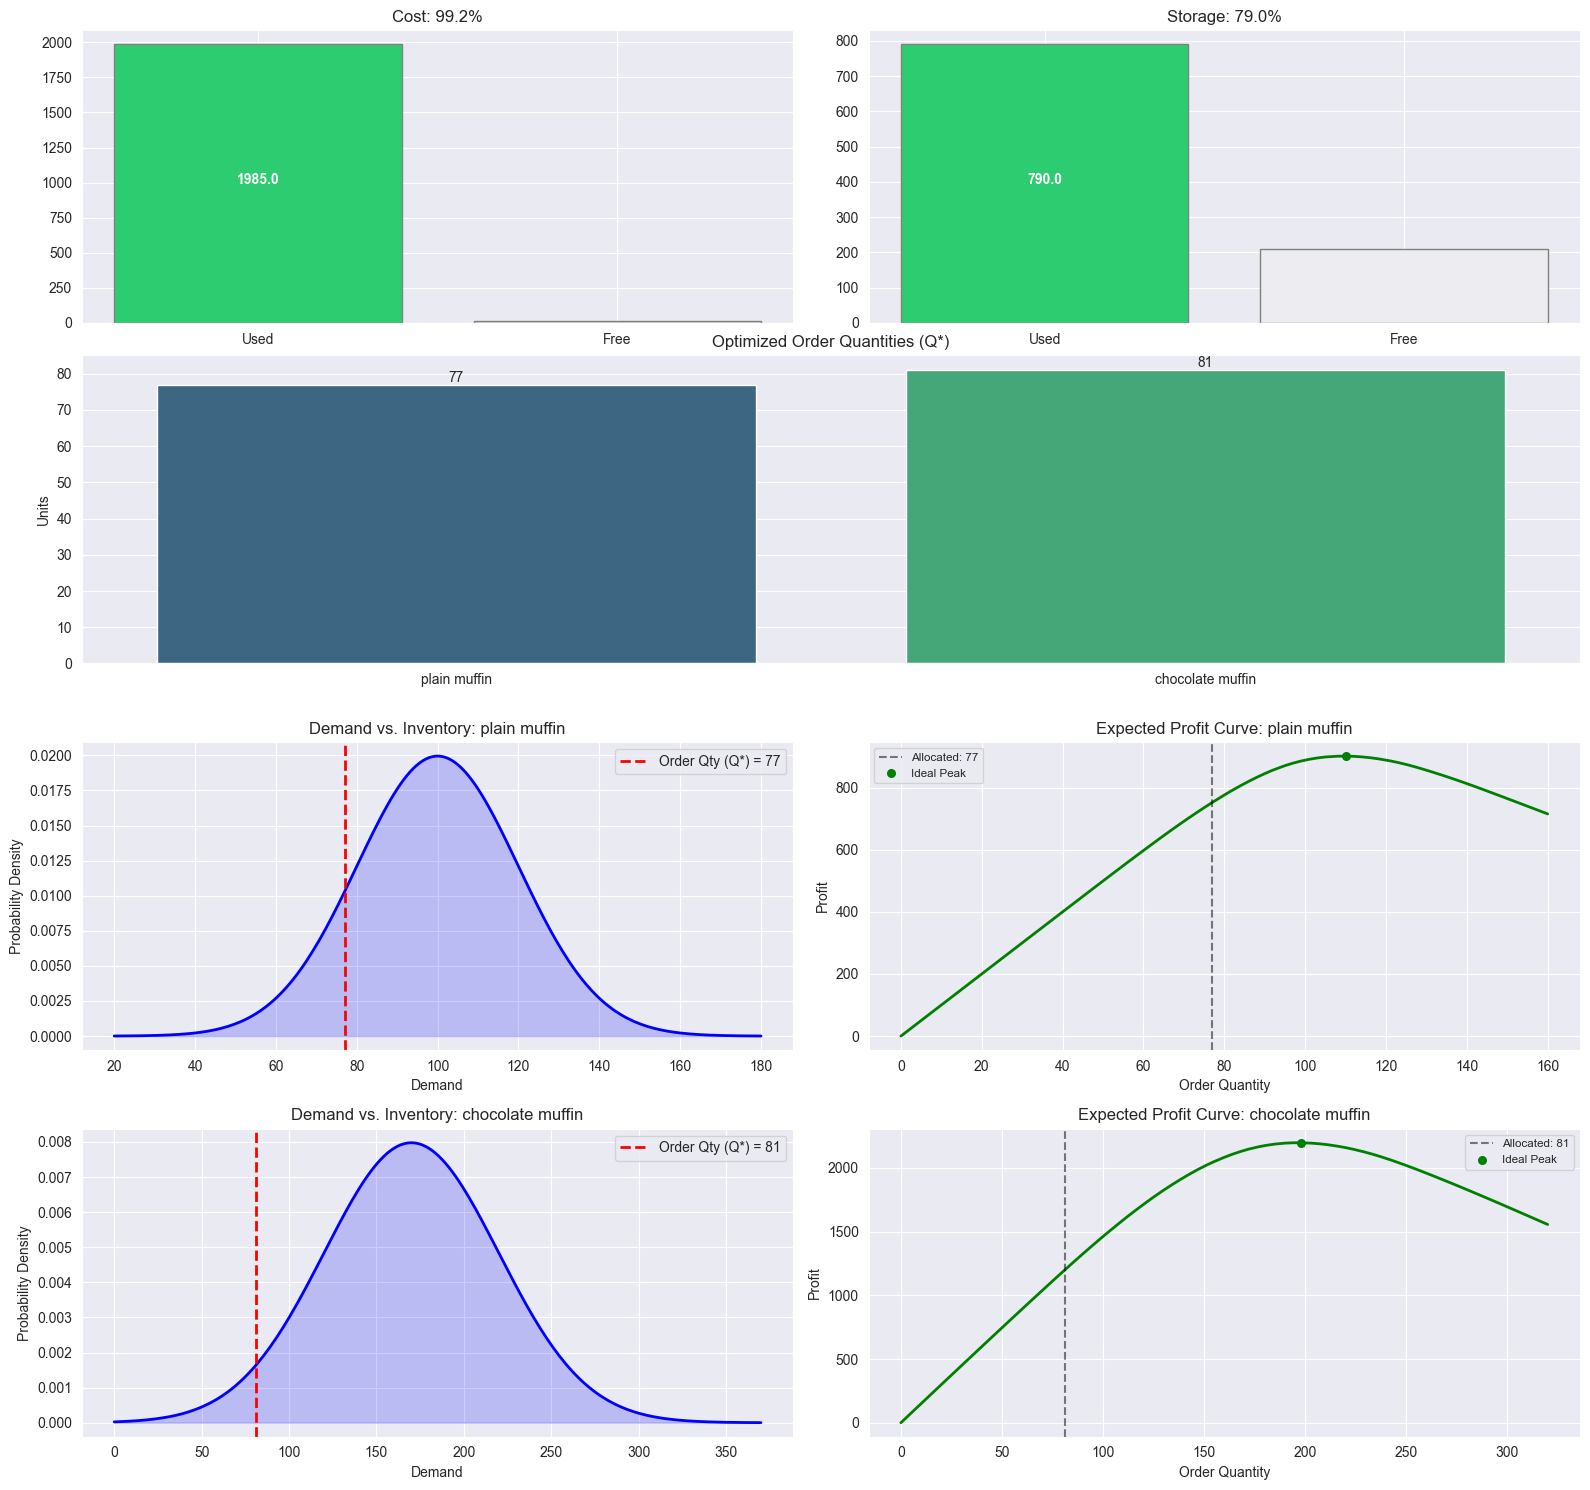

In [20]:
from inventory_management.solvers import ScipyOptimizationSolver
from inventory_management.plot_suite.portfolio import plot_constrained_allocation


plain_muffin = Item("plain muffin", cost_price=10, selling_price=20, salvage_value=5, constraints={"cost" : 10, "storage" : 5})
chocolate_muffin = Item(
    "chocolate muffin", cost_price=15, selling_price=30, salvage_value=8, constraints={"cost" : 15, "storage" : 5}
)

plain_demand = NormalDemand(100, 20)
chocolate_demand = NormalDemand(170, 50)

inventory_problems = problems = [
    (plain_muffin, plain_demand),
    (chocolate_muffin, chocolate_demand),
]

solver = ScipyOptimizationSolver(inventory_problems, limits = {"cost" : 2000, "storage" : 1000})
opt_allocation = solver.solve()
fig = plot_constrained_allocation(opt_allocation, problems, solver.limits)

- view multiplers
- see which constraints matter

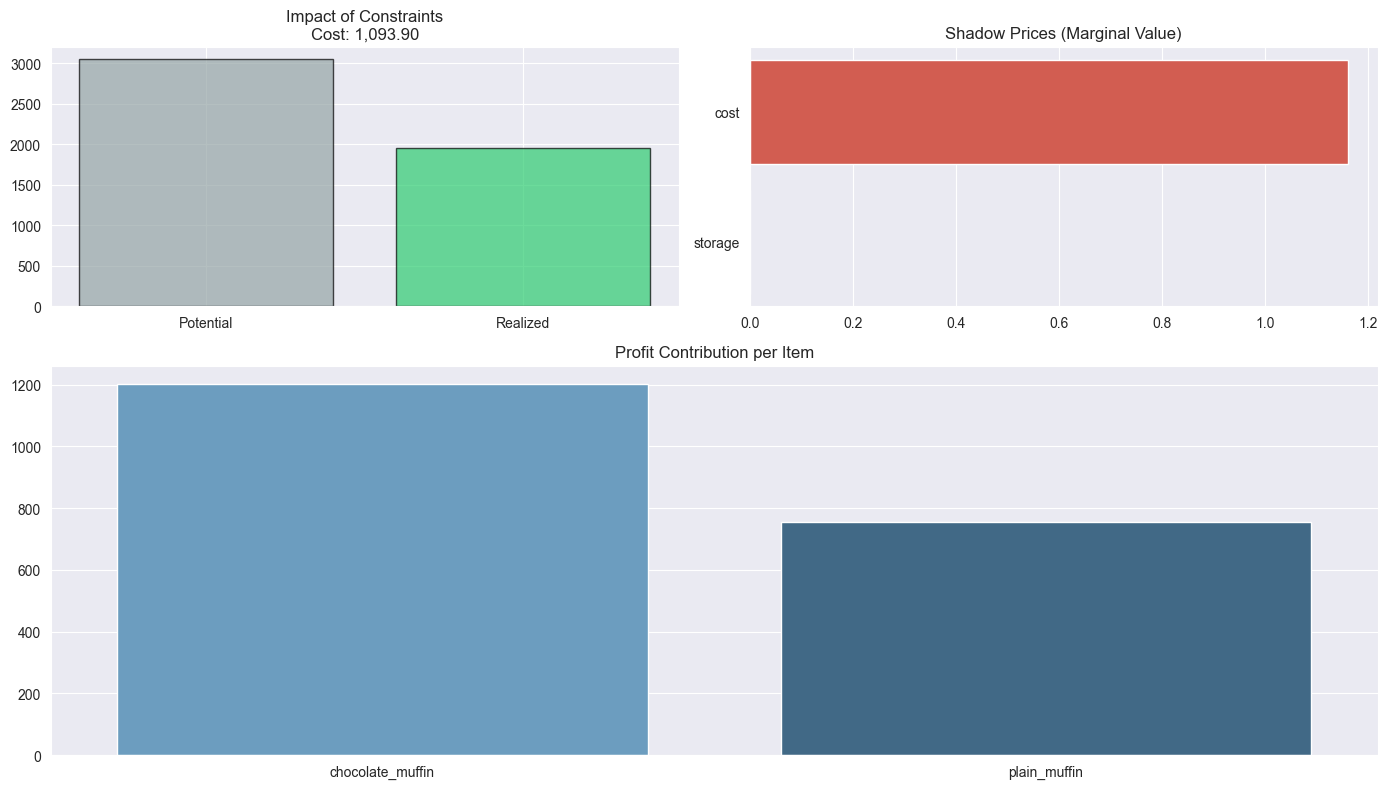

In [18]:
from inventory_management.plot_suite.portfolio import plot_optimization_summary
fig = plot_optimization_summary(opt_allocation, problems, solver.lambdas)